In [65]:
import pandas as pd
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
import numpy as np

In [66]:
data = pd.read_csv('/content/wine-clustering.csv')
data

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


In [67]:
data.isna().sum()

,0
Alcohol,0
Malic_Acid,0
Ash,0
Ash_Alcanity,0
Magnesium,0
Total_Phenols,0
Flavanoids,0
Nonflavanoid_Phenols,0
Proanthocyanins,0
Color_Intensity,0


In [68]:
X = data.select_dtypes(include= ['int64' , 'float64'])
scaled = StandardScaler()
X_scaled = scaled.fit_transform(X)

In [69]:
dbscan = DBSCAN(
    eps = 2.0,
    min_samples=5
)
clusters = dbscan.fit_predict(X_scaled)


In [70]:
data['clusters'] = clusters
data.head()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline,clusters
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,0
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,0
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,0
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,0
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,-1


In [71]:
n_clusters = len(set(clusters))- (1 if -1 in clusters else 0)
n_clusters

5

In [72]:
noise_points = list(clusters).count(-1)
noise_points

85

In [73]:
data.shape

(178, 14)

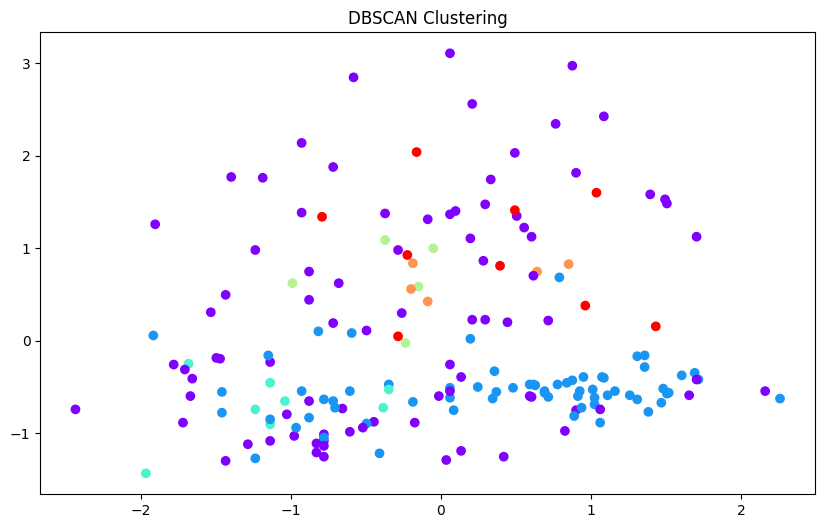

In [74]:
plt.figure(figsize=(10,6))
plt.scatter(X_scaled[:,0],
            X_scaled[:,1],
            c=clusters,
            cmap='rainbow')
plt.title('DBSCAN Clustering')
plt.show()

In [75]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

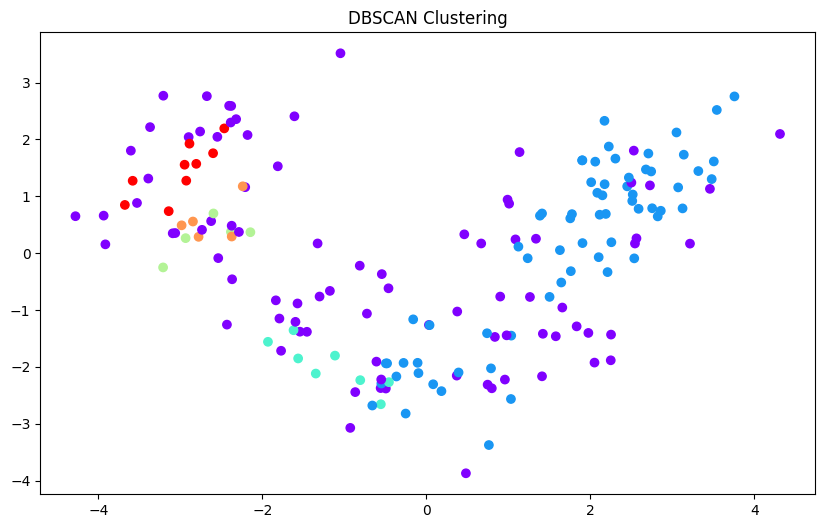

In [76]:
plt.figure(figsize=(10,6))
plt.scatter(X_pca[:,0],
            X_pca[:,1],
            c=clusters,
            cmap='rainbow')
plt.title('DBSCAN Clustering')
plt.show()

### Determining Optimal `eps` using K-distance Plot

Since DBSCAN classified all points as noise, we need to re-evaluate the `eps` parameter. A common method to find a suitable `eps` is to plot the K-distance graph. This graph shows the distance from each point to its k-th nearest neighbor, sorted in ascending order. The 'elbow' in this graph often indicates a good choice for `eps`.

For the K-distance plot, we'll use `min_samples` as the `n_neighbors` value in `NearestNeighbors`. Let's assume `min_samples` to be 5 as a starting point, which is a common value.

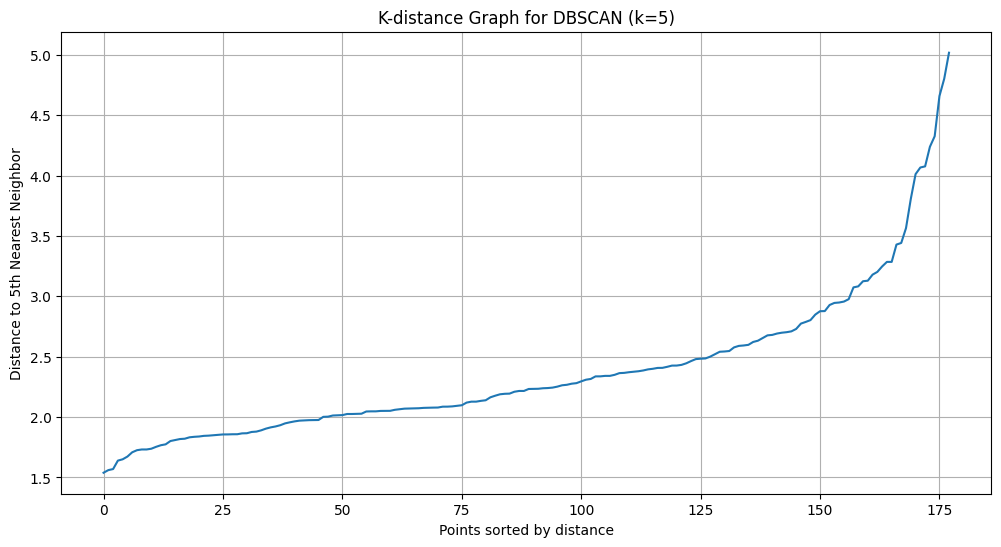

In [78]:


# Calculate the distance to the 5th nearest neighbor for each point
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

# Sort the distances in ascending order
distances = np.sort(distances[:, 4], axis=0) # Use the 5th column (index 4) for the 5th nearest neighbor

# Plot the K-distance graph
plt.figure(figsize=(12, 6))
plt.plot(distances)
plt.title('K-distance Graph for DBSCAN (k=5)')
plt.xlabel('Points sorted by distance')
plt.ylabel('Distance to 5th Nearest Neighbor')
plt.grid(True)
plt.show()